In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def bins(flt):
    if flt >=0.5:
        return (2)
    if flt < 0.5:
        return (1)
    else:
        print("input is not float between 0 and inf")
        
def missing(lst1,lst2):
    missing=[]
    list2=lst2.split(", ")
    for item in lst1:
        if item not in list2:
            missing.append(item)
        elif item in list2:
            continue
        else:
            print("Not present or absent?!? Consult Schrodinger and/or his cats.Leave Pavlov's dog out of it.")
    m=", ".join(missing)
    return(m)
        

In [6]:
mafft = pd.read_excel("aaRS_tRNAprocessing/presence_absence_collapseoldnewmodels.xlsx")
ortho = pd.read_csv("aaRS_tRNAprocessing_orthogroups.csv")
mafft=pd.merge(ortho, mafft, on='Orthogroup', how='left')
mafft

,targeting,description,Orthogroup,Species,Gene,Aligned,Gaps,Total,Percent_Longest_Athal
0,cytosolic,AlaRS,OG0004628,Athal,Athal_AT1G50200,1003,0,1003,1.000000
1,cytosolic,AlaRS,OG0004628,Atricho,Atricho_006826671.1,996,0,996,0.993021
2,cytosolic,AlaRS,OG0004628,Bfungosa,"Bfungosa_DN4391_c0_g1, Bfungosa_CNCB_GWHPDONK0...","954, 1021, 1021","0, 0, 0",954,1.017946
3,cytosolic,AlaRS,OG0004628,Caus,Caus_RAL46944.1,1059,0,1059,1.055833
4,cytosolic,AlaRS,OG0004628,Ccam,"Ccam_VFQ73684.1, Ccam_VFQ73750.1, Ccam_VFQ81428.1","1024, 1024, 322","0, 0, 0",1024,1.020937
...,...,...,...,...,...,...,...,...,...
1103,tRNA_processing,tRNaseZ3/4 mito/nuclear,OG0003316,Sasi,Sasi_GER52685.1,898,0,898,0.953291
1104,tRNA_processing,tRNaseZ3/4 mito/nuclear,OG0003316,Shimalayana,"Shimalayana_SHI11014, Shimalayana_SHI11017, Sh...","670, 157, 752, 227","0, 0, 0, 0",670,0.798301
1105,tRNA_processing,tRNaseZ3/4 mito/nuclear,OG0003316,Spolyrhiza,Spolyrhiza_Spipo26G0000900,909,0,909,0.964968
1106,tRNA_processing,tRNaseZ3/4 mito/nuclear,OG0003316,Valbum,"Valbum_Gs34718, Valbum_Gs35916, Valbum_Gs35917","962, 962, 334","0, 0, 0",962,1.021231


In [7]:
#Check we aren't missing data for any species or proteins
mafft[mafft['Species'].isna()]
mafft[mafft['description'].isna()]


,targeting,description,Orthogroup,Species,Gene,Aligned,Gaps,Total,Percent_Longest_Athal


In [8]:

#Sort orthologues based on length relative to A. thalaina model 
mafft["Presence_Absence"]=mafft.loc[:,"Percent_Longest_Athal"].apply(bins)
mafft

,targeting,description,Orthogroup,Species,Gene,Aligned,Gaps,Total,Percent_Longest_Athal,Presence_Absence
0,cytosolic,AlaRS,OG0004628,Athal,Athal_AT1G50200,1003,0,1003,1.000000,2
1,cytosolic,AlaRS,OG0004628,Atricho,Atricho_006826671.1,996,0,996,0.993021,2
2,cytosolic,AlaRS,OG0004628,Bfungosa,"Bfungosa_DN4391_c0_g1, Bfungosa_CNCB_GWHPDONK0...","954, 1021, 1021","0, 0, 0",954,1.017946,2
3,cytosolic,AlaRS,OG0004628,Caus,Caus_RAL46944.1,1059,0,1059,1.055833,2
4,cytosolic,AlaRS,OG0004628,Ccam,"Ccam_VFQ73684.1, Ccam_VFQ73750.1, Ccam_VFQ81428.1","1024, 1024, 322","0, 0, 0",1024,1.020937,2
...,...,...,...,...,...,...,...,...,...,...
1103,tRNA_processing,tRNaseZ3/4 mito/nuclear,OG0003316,Sasi,Sasi_GER52685.1,898,0,898,0.953291,2
1104,tRNA_processing,tRNaseZ3/4 mito/nuclear,OG0003316,Shimalayana,"Shimalayana_SHI11014, Shimalayana_SHI11017, Sh...","670, 157, 752, 227","0, 0, 0, 0",670,0.798301,2
1105,tRNA_processing,tRNaseZ3/4 mito/nuclear,OG0003316,Spolyrhiza,Spolyrhiza_Spipo26G0000900,909,0,909,0.964968,2
1106,tRNA_processing,tRNaseZ3/4 mito/nuclear,OG0003316,Valbum,"Valbum_Gs34718, Valbum_Gs35916, Valbum_Gs35917","962, 962, 334","0, 0, 0",962,1.021231,2


In [9]:
#Get names of species
species = mafft['Species'].drop_duplicates().tolist()
species

['Athal',
 'Atricho',
 'Bfungosa',
 'Caus',
 'Ccam',
 'Dcari',
 'Eaphy',
 'Eroseum',
 'Hmono',
 'Itrif',
 'Mesc',
 'Mgut',
 'Moleifera',
 'Osativa',
 'Pequestris',
 'Pjap',
 'Rcantleyi',
 'Rphallo',
 'Rwill',
 'Salbum',
 'Sasi',
 'Shimalayana',
 'Spolyrhiza',
 'Vvinifera',
 'Valbum']

In [10]:
combos=mafft.loc[:,["Orthogroup","Species"]].groupby('Orthogroup').agg({
    'Species':', '.join
})
combos['Absent'] = combos.loc[:,"Species"].apply(lambda x:missing(species,x))    
absent= combos.drop(columns='Species').loc[combos['Absent'] != "",:]
absent2 = pd.DataFrame(absent.Absent.str.split(', ').tolist(), index=absent.index).stack().reset_index([0, 'Orthogroup'])
absent2.columns= ['Orthogroup', 'Species']
absent2[['Gene','Aligned', 'Gaps', 'Total', 'Percent_Longest_Athal']] = "NaN"
absent2['Presence_Absence']= 0
absent3 = pd.merge(ortho, absent2)
mafft= pd.concat([mafft,absent3]).sort_values('description').reset_index(drop= True)
plot =mafft[['targeting','description','Orthogroup','Species', "Presence_Absence"]]
plot=plot.pivot(index=['targeting','description'],columns='Species', values='Presence_Absence') 

In [11]:
plot = plot.rename(columns ={
    'Atricho':'Amborella trichopoda',
    'Athal': 'Arabidopsis thaliana',
    'Bfungosa' : 'Balanophora fungosa',
    'Caus' : 'Cuscuta australis',
    'Ccam' : 'Cuscuta campestris',
    'Dcari' : 'Dendropemon caribaeus',
    'Eaphy' : 'Epipogium aphyllum',
    'Eroseum' : 'Epipogium roseum',
    'Hmono' : 'Monotropa hypopitys',
    'Itrif' : 'Ipomoea trifida',
    'Mesc' : 'Manihot esculenta',
    'Mgut' : 'Mimulus guttatus',
    'Moleifera' : 'Malania oleifera',
    'Osativa' : 'Oryza sativa',
    'Pequestris' : 'Phalaenopsis equestris',
    'Pjap' : 'Phtheirospermum japonicum',
    'Rcantleyi': 'Rafflesia cantleyi',
    'Rphallo': 'Rhopalocnemis phalloides',
    'Rwill' : 'Rhododendron williamsianum',
    'Salbum': 'Santalum album',
    'Sasi': 'Striga asiatica',
    'Shimalayana': 'Sapria himalayana',
    'Spolyrhiza': 'Spirodela polyrhiza',
    'Valbum':'Viscum album',
    'Vvinifera': 'Vitis vinifera'
    })

#plot.to_csv("aaRS_tRNAprocessing/20240805_aaRS_processing_collapsemodels.csv")


In [12]:
holo = ['Epipogium aphyllum','Epipogium roseum','Rafflesia cantleyi','Sapria himalayana','Shimalayanadenovo','Shimalayanaprotnew','Rhopalocnemis phalloides','Balanophora fungosa','BfungosaCNCB','BfungosacNGB','Monotropa hypopitys']
hemi =['Malania oleifera','Dendropemon caribaeus','Santalum album','Viscum album','Cuscuta australis','Cuscuta campestris','Striga asiatica','Phtheirospermum japonicum']
plot2=pd.DataFrame()
for cols in plot.columns:
        if cols in hemi:
            plot2[cols]= plot[cols].replace([1,2],[3,4])
        elif cols in holo:
            plot2[cols]= plot[cols].replace([1,2],[5,6])
        else:
            plot2[cols]= plot[cols]



plot2 = plot2[['Amborella trichopoda','Spirodela polyrhiza', 'Oryza sativa', 'Phalaenopsis equestris', 'Epipogium aphyllum', 'Epipogium roseum','Vitis vinifera','Arabidopsis thaliana','Manihot esculenta','Rafflesia cantleyi','Sapria himalayana','Malania oleifera','Dendropemon caribaeus','Rhopalocnemis phalloides','Balanophora fungosa','Santalum album','Viscum album','Rhododendron williamsianum','Monotropa hypopitys','Ipomoea trifida','Cuscuta australis','Cuscuta campestris','Mimulus guttatus','Striga asiatica','Phtheirospermum japonicum']].sort_index()
plot2


Amborella trichopoda  \
targeting       description                                      
cytosolic       AlaRS                                        2   
                AsnRS                                        2   
                AspRS                                        2   
                CysRS                                        0   
                GlnRS                                        2   
                GluRS                                        2   
                GlyRS                                        2   
                HisRS                                        2   
                IleRS                                        2   
                LeuRS                                        2   
                LysRS                                        2   
                MetRS                                        2   
                PheRSA                                       2   
                PheRSB                                       2   
                ProRS                                        2   
                SerRS                                        2   
                ThrRS                                        2   
                TrpRS                                        2   
                TyrRS                                        2   
                ValRS                                        2   
organellar      AlaRS                                        2   
                AsnRS                                        2   
                AspRS                                        2   
                CysRS                                        2   
                GluRS                                        2   
                GlyRS                                        2   
                HisRS                                        2   
                IleRS                                        2   
                LeuRS                                        2   
                LysRS                                        2   
                MetRS                                        2   
                PheRS                                        2   
                ProRS                                        2   
                SerRS                                        2   
                ThrRS                                        2   
                TrpRS                                        2   
                TyrRS                                        2   
                ValRS                                        2   
tRNA_processing CCAse                                        2   
                GatA                                         2   
                GatB                                         2   
                GatC                                         2   
                PRORP1 organellar                            2   
                PRORP2/3 nuclear                             2   
                putative MTF                                 2   
                putative Tils                                2   
                tRNaseZ1 cytosolic                           2   
                tRNaseZ2 plastid                             2   
                tRNaseZ3/4 mito/nuclear                      2   

                                          Spirodela polyrhiza  Oryza sativa  \
targeting       description                                                   
cytosolic       AlaRS                                       2             2   
                AsnRS                                       2             2   
                AspRS                                       2             2   
                CysRS                                       2             2   
                GlnRS                                       2             2   
                GluRS                                       2             2   
                GlyRS                      

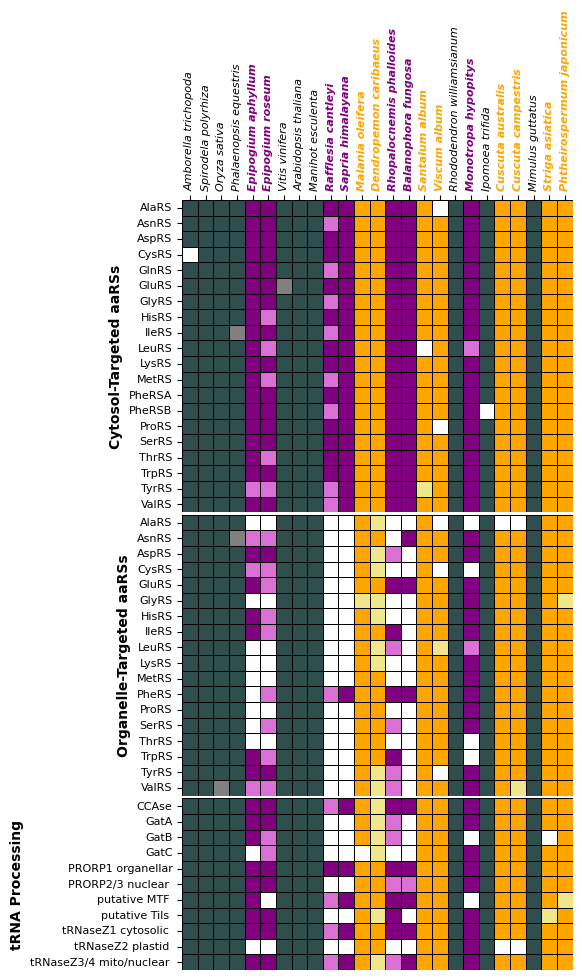

In [14]:
###aaRS and tRNA######


#Divide into 3 dataframes to plot:
plotaaRS= plot2.filter(regex='RS', axis=0)
notRS= plot2.filter(regex='^((?!RS).)*$', axis=0)
notRS=notRS.loc['tRNA_processing',:]
plotorgaaRS= plotaaRS.loc['organellar',:]
plotcytaaRS= plotaaRS.loc['cytosolic',:]

##Generate heatmap###
height_ratios=[len(plot2.loc['cytosolic']), len(plot2.loc['organellar']),len(plot2.loc['tRNA_processing'])] # set aspect ratios based on # rows
radcolors =['white','grey','darkslategrey', 'khaki', 'orange','orchid','purple'] #generate color scheme
fig, ax = plt.subplots(3, 1, figsize=(6, 10),gridspec_kw={'height_ratios': height_ratios}) #set figure size, # of subplots, and thier aspect ratios
fig.subplots_adjust(wspace=0, hspace=.01)

#Plot cytosolic aaRS
cyt = sns.heatmap(plotcytaaRS,cmap=radcolors,linewidths=.5, linecolor='black',cbar=False,ax=ax[0], square=True)
cyt.set_ylabel("Cytosol-Targeted aaRSs", fontweight="bold") 
cyt.xaxis.tick_top() # x axis on top
cyt.xaxis.set_label_position('top')
cyt.set_xticklabels(cyt.get_xticklabels(), rotation=90,fontsize = 8)
cyt.set_yticklabels(cyt.get_yticklabels(),fontsize = 8)
for text in cyt.get_xticklabels():
    text.set_style('italic')
    if text.get_text() in holo:
        text.set_weight('bold')
        text.set_color('purple')
    if text.get_text() in hemi:
        text.set_weight('bold')
        text.set_color('orange')

#Plot organellar aaRS
org = sns.heatmap(plotorgaaRS,cmap=radcolors,linewidths=.5,cbar=False, linecolor='black',ax=ax[1], square=True)
org.set(xticklabels=[]) 
org.set_yticklabels(org.get_yticklabels(),fontsize = 8)
org.set_ylabel("Organelle-Targeted aaRSs", fontweight="bold")  
org.tick_params(bottom=False)  # remove the ticks

#plot processing enzymes
proc = sns.heatmap(notRS,cmap=radcolors,linewidths=.5, linecolor='black',cbar=False,ax=ax[2], square=True)
proc.set_ylabel("tRNA Processing", fontweight="bold") 
proc.set(xticklabels=[]) 
proc.set_yticklabels(proc.get_yticklabels(),fontsize = 8) 
proc.tick_params(bottom=False)  # remove the ticks

#save plot as .svg for upload into inkscape

plt.savefig('aaRS_tRNAprocessing/20240805_aaRS_processing_collapsemodels.svg', dpi=600)
